# <span style="color:#1E2D6B">PA-BI E-Commerce</span>  
## <span style="color:#E669B9">Machine Learning</span>

---

### <span style="color:#1E2D6B">Introduction</span>
Welcome to the <span style="color:#E669B9">Machine Learning</span> section.

---

### <span style="color:#1E2D6B">Applications</span>
- <span style="color:#E669B9">Product Recommendation</span>  
- <span style="color:#E669B9">Customer Segmentation</span>  

## <span style="color:#E669B9">Regression Task — Predictive Model</span>

---

### <span style="color:#1E2D6B">Objective</span>
Build a **predictive** regression model that estimates the **total order amount**
based only on information available **before** the order is placed:

- <span style="color:#E669B9">Target variable</span> : `Montant_de_la_commande` (order amount in TND)
- <span style="color:#E669B9">Use case</span> : *"A customer in Sfax is browsing ceramics at 200 TND catalogue price in December — how much will they likely spend?"*

---

### <span style="color:#1E2D6B">Key Design Decision</span>
We intentionally **exclude** features only known at order time (quantity, unit price, discount, delivery).
This makes the model genuinely **predictive** rather than a calculator.

The output includes:
- **Predicted order amount** (TND)
- **Estimated average quantity** = `predicted_amount / catalogue_price`

---

### <span style="color:#1E2D6B">Features Used</span>
Only pre-order knowledge:
- <span style="color:#E669B9">Product</span> : catalogue price, category, promo status, sales channel
- <span style="color:#E669B9">Client</span> : city
- <span style="color:#E669B9">Context</span> : month, season, year, payment method, promo code

---

### <span style="color:#1E2D6B">Models</span>
- <span style="color:#E669B9">Random Forest + Log-Transform</span>
- <span style="color:#E669B9">Gradient Boosting + Log-Transform</span>

Best model auto-selected and saved.


# Dependencies Instalation

In [1]:
pip install pyodbc sqlalchemy pandas

Note: you may need to restart the kernel to use updated packages.


# Datawarehouse Connexion

In [2]:
import pyodbc
import pandas as pd
from sqlalchemy import create_engine, text
import urllib
import numpy as np

# ── Paramètres de connexion ───────────────────────────────────
SERVER   = "SANA\MSSQLDEVELOPER" 
DATABASE = "DW_E-Commerce"      

# ── Chaîne de connexion ───────────────────────────────────────
connection_string = (
    f"DRIVER={{ODBC Driver 17 for SQL Server}};"
    f"SERVER={SERVER};"
    f"DATABASE={DATABASE};"
    f"Trusted_Connection=yes;"
)

params = urllib.parse.quote_plus(connection_string)
engine = create_engine(f"mssql+pyodbc:///?odbc_connect={params}")

try:
    with engine.connect() as conn:
        print("Connexion réussie !")
        result = conn.execute(text("SELECT DB_NAME() AS base_active"))  
        print("Base active :", result.fetchone()[0])
except Exception as e:
    print("Erreur de connexion :", e)

Connexion réussie !
Base active : DW_E-Commerce


# Tables Verification

In [3]:
df_tables = pd.read_sql(text("""
    SELECT TABLE_NAME
    FROM INFORMATION_SCHEMA.TABLES
    WHERE TABLE_TYPE = 'BASE TABLE'
    ORDER BY TABLE_NAME
"""), engine)

print("── Tables disponibles ──")
print(df_tables.to_string(index=False))

# ── Nombre de lignes par table ────────────────────────────────
tables = ['Fact_Ventes', 'Fact_Achats', 'Dim_Client',
          'Dim_Produit', 'DimDates', 'Dim_Geographie',
          'Dim_Type_Vente', 'Dim_Mode_Paiement',
          'Dim_Categorie', 'Dim_Fournisseur']

print("\n── Nombre de lignes par table ──")
for t in tables:
    try:
        n = pd.read_sql(text(f"SELECT COUNT(*) AS n FROM {t}"),
                        engine)['n'][0]
        print(f"  {t:30s} → {n:>8,} lignes")
    except:
        print(f"  {t:30s} → introuvable")

── Tables disponibles ──
              TABLE_NAME
  Dictionnaire_Categorie
 Dictionnaire_Geographie
           Dim_Categorie
              Dim_Client
         Dim_Fournisseur
          Dim_Geographie
       Dim_Mode_Paiement
             Dim_Produit
Dim_Produits_Concurrents
          Dim_Type_Vente
                DimDates
             Fact_Achats
             Fact_Ventes
      prediction_history
             sysdiagrams
           Ville_Tunisie

── Nombre de lignes par table ──
  Fact_Ventes                    →      831 lignes
  Fact_Achats                    →      270 lignes
  Dim_Client                     →      464 lignes
  Dim_Produit                    →      741 lignes
  DimDates                       →   36,891 lignes
  Dim_Geographie                 →       21 lignes
  Dim_Type_Vente                 →        2 lignes
  Dim_Mode_Paiement              →        9 lignes
  Dim_Categorie                  →       37 lignes
  Dim_Fournisseur                →       78 lignes


In [4]:
import sys
!{sys.executable} -m pip install --upgrade scikit-learn

In [5]:
import sklearn
print(sklearn.__version__)

1.8.0


# Fact table overview

In [6]:
# ── Aperçu Fact_Ventes ────────────────────────────────────────
print("── Structure Fact_Ventes ──")
df_struct = pd.read_sql(text("""
    SELECT COLUMN_NAME, DATA_TYPE
    FROM INFORMATION_SCHEMA.COLUMNS
    WHERE TABLE_NAME = 'Fact_Ventes'
    ORDER BY ORDINAL_POSITION
"""), engine)
print(df_struct.to_string(index=False))

# ── Statistiques descriptives des colonnes numériques ─────────
print("\n── Statistiques Fact_Ventes ──")
df_fact = pd.read_sql(text("""
    SELECT
        COUNT(*)                          AS nb_lignes,
        COUNT(DISTINCT Client_FK)         AS nb_clients,
        COUNT(DISTINCT Produit_FK)        AS nb_produits,
        COUNT(DISTINCT Numero_Facture)    AS nb_factures,
        COUNT(DISTINCT Numero_Commande)   AS nb_commandes_web,

        -- Cible : Montant_de_la_commande
        MIN(Montant_de_la_commande)       AS montant_min,
        MAX(Montant_de_la_commande)       AS montant_max,
        AVG(Montant_de_la_commande)       AS montant_moyen,

        -- Autres montants
        AVG(Montant_Remise)               AS remise_moyenne,
        AVG(Montant_Livraison)            AS livraison_moyenne,
        AVG(Prix_Unité)                   AS prix_unite_moyen,

        -- Quantité
        MIN(Quantite)                     AS qte_min,
        MAX(Quantite)                     AS qte_max,
        AVG(Quantite)                     AS qte_moyenne

    FROM Fact_Ventes
    WHERE Montant_de_la_commande > 0
"""), engine)
print(df_fact.T.to_string(header=False))

# ── Distribution de la cible ──────────────────────────────────
print("\n── Distribution Montant_de_la_commande ──")
df_dist = pd.read_sql(text("""
    SELECT
        PERCENTILE_CONT(0.25) WITHIN GROUP
            (ORDER BY Montant_de_la_commande) OVER () AS Q1,
        PERCENTILE_CONT(0.50) WITHIN GROUP
            (ORDER BY Montant_de_la_commande) OVER () AS mediane,
        PERCENTILE_CONT(0.75) WITHIN GROUP
            (ORDER BY Montant_de_la_commande) OVER () AS Q3,
        PERCENTILE_CONT(0.90) WITHIN GROUP
            (ORDER BY Montant_de_la_commande) OVER () AS P90,
        PERCENTILE_CONT(0.99) WITHIN GROUP
            (ORDER BY Montant_de_la_commande) OVER () AS P99
    FROM Fact_Ventes
    WHERE Montant_de_la_commande > 0
"""), engine)
print(df_dist.drop_duplicates().T.to_string(header=False))

── Structure Fact_Ventes ──
           COLUMN_NAME DATA_TYPE
              Vente_PK       int
               Date_FK       int
         Type_Vente_FK       int
            Produit_FK       int
          Categorie_FK       int
             Client_FK       int
         Geographie_FK       int
      Mode_Paiement_FK       int
              Quantite       int
     Montant_Livraison     float
 Montant_Remboursement     float
Montant_de_la_commande     float
        Montant_Remise     float
            Code_Promo  nvarchar
        Numero_Facture  nvarchar
       Numero_Commande  nvarchar
            Prix_Unité     float

── Statistiques Fact_Ventes ──
nb_lignes            831.000000
nb_clients           446.000000
nb_produits          210.000000
nb_factures           45.000000
nb_commandes_web     441.000000
montant_min           14.000000
montant_max        56525.000000
montant_moyen        538.923574
remise_moyenne         0.436221
livraison_moyenne      6.523466
prix_unite_moyen      55.2

# Dataframe Description :


## <span style="color:#E669B9">Target Variable</span>

| Column | Type | Description |
|--------|------|------------|
| Montant_de_la_commande | float | Total order value in TND |

---

## <span style="color:#E669B9">Features (Pre-Order Knowledge Only)</span>

| Column | Type | Description |
|--------|------|------------|
| prix_catalogue | float | Catalogue price of the product |
| En_Promo | int | Is product on promotion (0/1) |
| a_code_promo | int | Promo code used (0/1) |
| canal_produit | varchar | Sales channel |
| categorie | varchar | Product category |
| ville_client | varchar | Client city |
| type_paiement | varchar | Payment method |
| Annee | int | Year |
| Mois | int | Month |
| Trimestre | str | Quarter |
| Semestre | str | Semester |
| est_saison_haute | int | High season flag (Jun/Jul/Aug/Dec) |

---

## <span style="color:#E669B9">Columns Excluded</span>

| Column | Reason |
|--------|--------|
| Numero_Commande | Unique ID — memorization |
| Type_client | Single value (Particulier) |
| type_vente | Single value (Site_Web) |
| classe_prix | Derived from target — leakage |
| Quantite_totale | Only known at order time |
| Prix_Unité_moyen | Only known at order time |
| Montant_Remise | Only known at order time |
| Montant_Livraison | Only known at order time |
| remise_pct | Derived from excluded columns |
| ratio_prix_catalogue | Derived from excluded columns |

---


# DataFrame Construction

In [7]:
query_regression_b2c = text("""
SELECT
    fv.Numero_Commande,

    --  Cible (une seule valeur par commande)
    MAX(fv.Montant_de_la_commande) AS Montant_de_la_commande,

    --  Features agrégées (gardées dans le dataset pour analyse)
    SUM(fv.Quantite)           AS Quantite_totale,
    AVG(fv.Prix_Unité)         AS Prix_Unité_moyen,
    SUM(fv.Montant_Remise)     AS Montant_Remise,
    SUM(fv.Montant_Livraison)  AS Montant_Livraison,

    MAX(CASE WHEN fv.Code_Promo IS NOT NULL
         AND fv.Code_Promo != ''
         AND fv.Code_Promo != 'Aucun'
         THEN 1 ELSE 0 END) AS a_code_promo,

    --  Dimensions
    MAX(dc.Type_client)       AS Type_client,
    MAX(dc.Ville)             AS ville_client,
    MAX(dp.Prix)              AS prix_catalogue,
    CASE 
    WHEN MAX(CAST(dp.En_Promo AS INT)) = 1 THEN 1 
    ELSE 0 
END AS En_Promo,
    MAX(dp.Canal)             AS canal_produit,
    MAX(dcat.Categorie)       AS categorie,
    MAX(dtv.Type_Vente)       AS type_vente,
    MAX(dmp.Type_paiement)    AS type_paiement,

    --  Temps
    MAX(dd.Annee)             AS Annee,
    MAX(dd.Mois)              AS Mois,
    MAX(dd.Trimestre)         AS Trimestre,
    MAX(dd.Semestre)          AS Semestre,

    MAX(CASE WHEN dd.Mois IN (6,7,8,12)
         THEN 1 ELSE 0 END) AS est_saison_haute

FROM Fact_Ventes fv
JOIN Dim_Client dc   ON fv.Client_FK = dc.Client_PK
JOIN Dim_Produit dp  ON fv.Produit_FK = dp.Produit_PK
JOIN Dim_Categorie dcat ON fv.Categorie_FK = dcat.Categorie_PK
JOIN Dim_Type_Vente dtv ON fv.Type_Vente_FK = dtv.Type_Vente_PK
JOIN Dim_Mode_Paiement dmp ON fv.Mode_Paiement_FK = dmp.Mode_Paiement_PK
JOIN DimDates dd ON fv.Date_FK = dd.Date_PK

WHERE fv.Montant_de_la_commande > 0
AND dd.Date != '1111-11-11'
AND fv.Numero_Facture = 'Aucun'

GROUP BY fv.Numero_Commande
ORDER BY MAX(dd.Date)
""")

# ── Chargement ───────────────────────────────────────────────
df_reg = pd.read_sql(query_regression_b2c, engine)

print(f'Dataframe Shape : {df_reg.shape}')
print(f'\nVerification :')
print(f'  orders number: {df_reg["Numero_Commande"].nunique():,}')
print(f'  Total lines     : {len(df_reg):,}')

duplicates = df_reg['Numero_Commande'].duplicated().sum()
print(f'\nDoublons Numero_Commande : {duplicates}')

col_target = 'Montant_de_la_commande'
if col_target in df_reg.columns:
    print(f'\nTarget Statistics :')
    print(df_reg[col_target].describe().round(2))
else:
    raise ValueError(f'Colonne {col_target} introuvable')

# Pas de feature engineering ici (remise_pct, ratio_prix_catalogue)
# car ces features dépendent de colonnes exclues du modèle prédictif

if 'Type_client' in df_reg.columns:
    print(f'\nType_client unique : {df_reg["Type_client"].unique()}')

print(f'\nMissing Values :')
missing = df_reg.isnull().sum()
print(missing[missing > 0])

print(f'\n Final B2C DataFrame  :')
print(f'  Rows   : {df_reg.shape[0]:,}')
print(f'  Columns : {df_reg.shape[1]}')


Dataframe Shape : (440, 20)

Verification :
  orders number: 440
  Total lines     : 440

Doublons Numero_Commande : 0

Target Statistics :
count     440.00
mean      120.71
std       420.20
min        14.00
25%        68.75
50%        92.00
75%       104.00
max      6386.56
Name: Montant_de_la_commande, dtype: float64

Type_client unique : ['Particulier']

Missing Values :
ville_client    1
dtype: int64

 Final B2C DataFrame  :
  Rows   : 440
  Columns : 20


In [8]:
# ═══════════════════════════════════════════════════════════════
# DATA FILTERING + OUTLIER TREATMENT
# ═══════════════════════════════════════════════════════════════
# 1) On retire les commandes < 50 TND (trop de bruit,
#    MAE de 12 TND = 40% d'erreur sur ces commandes)
# 2) On cap les extrêmes au P99
# ═══════════════════════════════════════════════════════════════

col = 'Montant_de_la_commande'
SEUIL_MIN = 50  # TND — seuil minimum pour le modèle

print('── Avant filtrage ──')
print(f'  Lignes : {len(df_reg)}')
print(f'  Min    : {df_reg[col].min():.2f} TND')
print(f'  Max    : {df_reg[col].max():.2f} TND')
print(f'  Median : {df_reg[col].median():.2f} TND')
print(f'  Mean   : {df_reg[col].mean():.2f} TND')

# ── Étape 1 : Retirer les petites commandes ─────────────
n_before = len(df_reg)
df_reg = df_reg[df_reg[col] >= SEUIL_MIN].reset_index(drop=True)
n_removed = n_before - len(df_reg)

print(f'\n── Après filtrage >= {SEUIL_MIN} TND ──')
print(f'  Lignes supprimées : {n_removed}')
print(f'  Lignes restantes  : {len(df_reg)}')

# ── Étape 2 : Capping P99 ───────────────────────────────
p99 = df_reg[col].quantile(0.99)
p01 = df_reg[col].quantile(0.01)
df_reg[col] = df_reg[col].clip(lower=p01, upper=p99)

print(f'\n── Après capping P1/P99 ──')
print(f'  Min    : {df_reg[col].min():.2f} TND')
print(f'  Max    : {df_reg[col].max():.2f} TND')
print(f'  Median : {df_reg[col].median():.2f} TND')
print(f'  Mean   : {df_reg[col].mean():.2f} TND')
print(f'\n→ Le modèle prédit uniquement les commandes >= {SEUIL_MIN} TND')
print(f'→ Le frontend doit valider : prix_catalogue >= {SEUIL_MIN} TND')


── Avant filtrage ──
  Lignes : 440
  Min    : 14.00 TND
  Max    : 6386.56 TND
  Median : 92.00 TND
  Mean   : 120.71 TND

── Après filtrage >= 50 TND ──
  Lignes supprimées : 68
  Lignes restantes  : 372

── Après capping P1/P99 ──
  Min    : 50.00 TND
  Max    : 334.39 TND
  Median : 98.95 TND
  Mean   : 102.19 TND

→ Le modèle prédit uniquement les commandes >= 50 TND
→ Le frontend doit valider : prix_catalogue >= 50 TND


In [9]:
import sklearn, sys
print(sklearn.__version__)   # doit être 1.8.0
print(sys.executable)        # doit pointer vers anaconda3

1.8.0
c:\Users\eree\anaconda3\python.exe


# Target Distribution 

══════════════════════════════════════════════════
  TARGET DIAGNOSTIC
══════════════════════════════════════════════════
count    372.000000
mean     102.194247
std       40.159427
min       50.000000
25%       90.000000
50%       98.950000
75%      106.125000
max      334.390000
Name: Montant_de_la_commande, dtype: float64

Skewness (original) : 3.23
Skewness (log1p)    : 0.73


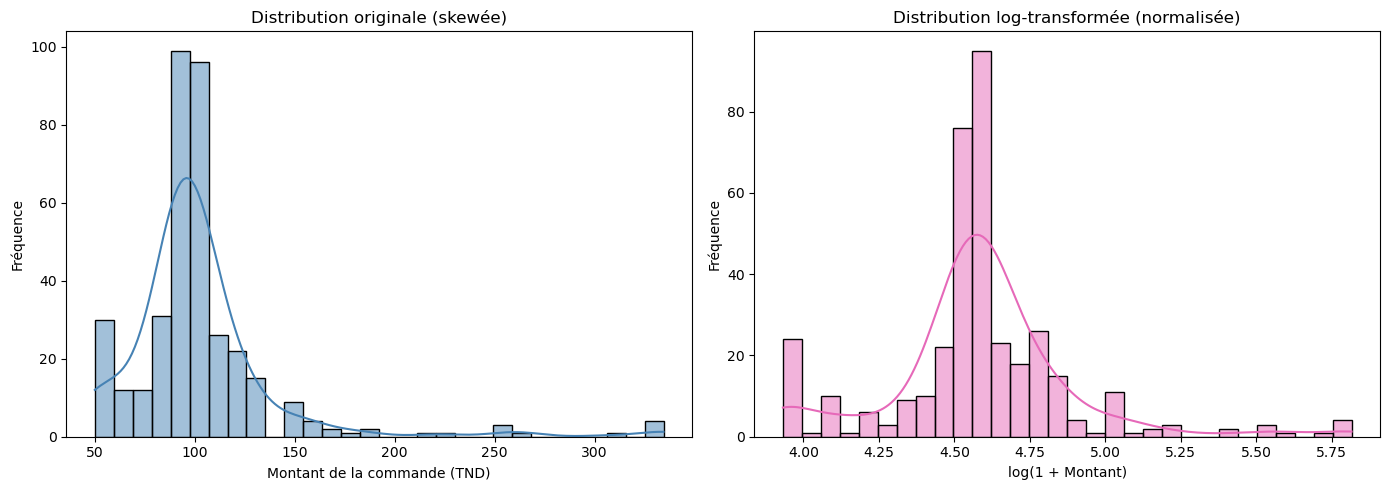


→ La transformation log1p réduit fortement le skewness
→ Le modèle apprendra mieux sur cette distribution normalisée


In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

print('═' * 50)
print('  TARGET DIAGNOSTIC')
print('═' * 50)

target = df_reg['Montant_de_la_commande']
target_log = np.log1p(target)

print(target.describe())
print(f'\nSkewness (original) : {target.skew():.2f}')
print(f'Skewness (log1p)    : {target_log.skew():.2f}')

# ── Comparaison : Original vs Log-transformed ──────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(target, bins=30, kde=True, ax=axes[0], color='steelblue')
axes[0].set_title('Distribution originale (skewée)')
axes[0].set_xlabel('Montant de la commande (TND)')
axes[0].set_ylabel('Fréquence')

sns.histplot(target_log, bins=30, kde=True, ax=axes[1], color='#E669B9')
axes[1].set_title('Distribution log-transformée (normalisée)')
axes[1].set_xlabel('log(1 + Montant)')
axes[1].set_ylabel('Fréquence')

plt.tight_layout()
plt.show()

print('\n→ La transformation log1p réduit fortement le skewness')
print('→ Le modèle apprendra mieux sur cette distribution normalisée')


# Visualisation 

📊 Intervalles de prix :
Basse   : [50.00 → 90.00] TND
Moyenne : [90.00 → 100.00] TND
Chère   : [100.00 → 334.39] TND


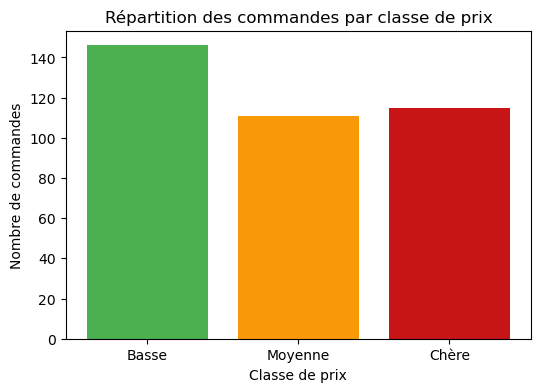

In [11]:
import pandas as pd
import matplotlib.pyplot as plt

# ── Création TEMPORAIRE des 3 classes de prix (visualisation uniquement) ──
classe_prix_temp = pd.qcut(
    df_reg['Montant_de_la_commande'],
    q=3,
    labels=['Basse', 'Moyenne', 'Chère']
)

# ── Récupération des bornes (intervalles) ──────────────────
bins = pd.qcut(df_reg['Montant_de_la_commande'], q=3, retbins=True)[1]

print("📊 Intervalles de prix :")
print(f"Basse   : [{bins[0]:.2f} → {bins[1]:.2f}] TND")
print(f"Moyenne : [{bins[1]:.2f} → {bins[2]:.2f}] TND")
print(f"Chère   : [{bins[2]:.2f} → {bins[3]:.2f}] TND")

# ── Comptage des classes ───────────────────────────────────
counts = classe_prix_temp.value_counts().sort_index()

# ── Couleurs ───────────────────────────────────────────────
colors = ["#4CAF50", "#F99908", "#C81515"]

# ── Visualisation ───────────────────────────────────────────
plt.figure(figsize=(6,4))
plt.bar(counts.index, counts.values, color=colors)

plt.title("Répartition des commandes par classe de prix")
plt.xlabel("Classe de prix")
plt.ylabel("Nombre de commandes")

plt.show()

# ⚠️ On ne garde PAS classe_prix dans df_reg
# C'est dérivé de la target → data leakage si inclus dans X
if "classe_prix" in df_reg.columns:
    df_reg = df_reg.drop(columns=["classe_prix"])
    print("✅ classe_prix supprimée de df_reg (éviter le data leakage)")



📊 Intervalles de prix :


<span style="color:#4CAF50">  Basse   : [18.00 → 85.00] TND </span>


<span style="color:#F99908">  Moyenne : [85.00 → 100.00] TND </span>


<span style="color:#C81515">  Chère   : [100.00 → 156.00] TND</span>

# Random Forest Regressor (with Log-Transform)


In [12]:
# ── Target ────────────────────────────────────────────────────
y = df_reg['Montant_de_la_commande']

# ── Colonnes à exclure ────────────────────────────────────────
# On garde UNIQUEMENT les infos connues AVANT la commande
# Tout ce qui est connu seulement au moment de la commande est exclu

cols_to_drop = [
    'Montant_de_la_commande',   # target
    'Numero_Commande',           # ID unique
    'Type_client',               # single value (toujours Particulier)
    'type_vente',                # single value (toujours Site_Web)
    'classe_prix',               # target leakage
    # ── Colonnes connues seulement au moment de la commande ──
    'Quantite_totale',           # combien le client achète
    'Prix_Unité_moyen',          # prix négocié / réduit
    'Montant_Remise',            # remise accordée
    'Montant_Livraison',         # frais de livraison
    'remise_pct',                # dérivée de Montant_Remise
    'ratio_prix_catalogue',      # dérivée de Prix_Unité_moyen
]

X = df_reg.drop(columns=[c for c in cols_to_drop if c in df_reg.columns])

print(f'X shape : {X.shape}')
print(f'y shape : {y.shape}')
print(f'\nFeatures prédictives ({len(X.columns)}) :')
for col in X.columns:
    print(f'  - {col} ({X[col].dtype})')

print(f'\n→ Que des infos connues AVANT la commande')
print(f'→ Le modèle prédit le montant total à partir du contexte')


X shape : (372, 12)
y shape : (372,)

Features prédictives (12) :
  - a_code_promo (int64)
  - ville_client (object)
  - prix_catalogue (float64)
  - En_Promo (int64)
  - canal_produit (object)
  - categorie (object)
  - type_paiement (object)
  - Annee (int64)
  - Mois (int64)
  - Trimestre (object)
  - Semestre (object)
  - est_saison_haute (int64)

→ Que des infos connues AVANT la commande
→ Le modèle prédit le montant total à partir du contexte


In [13]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [14]:
print("X_train shape : "+str(X_train.shape)+" | X_test shape : "+str(X_test.shape))
print("y_train shape : "+str(y_train.shape)+" | y_test shape : "+str(y_test.shape))

X_train shape : (297, 12) | X_test shape : (75, 12)
y_train shape : (297,) | y_test shape : (75,)


In [15]:
from sklearn.model_selection import GridSearchCV
from sklearn.compose import ColumnTransformer, TransformedTargetRegressor
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor

# ── Colonnes ─────────────────────────────────────────
num_cols = X.select_dtypes(include=['int64', 'float64']).columns
cat_cols = X.select_dtypes(include=['object', 'category']).columns

print('Num cols:', list(num_cols))
print('Cat cols:', list(cat_cols))

# ── Preprocessing ────────────────────────────────────
preprocessor = ColumnTransformer([
    ('num', StandardScaler(), num_cols),
    ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)
])

# ── Pipeline interne ─────────────────────────────────
pipe_rf = Pipeline([
    ('prep', preprocessor),
    ('model', RandomForestRegressor(random_state=42))
])

# ── TransformedTargetRegressor ────────────────────────
# Entraîne sur log1p(y), prédit en expm1(y_hat)
# Le .pkl sauvegardé inclura la transformation
# → regression.py n'a PAS besoin de changement
wrapped_rf = TransformedTargetRegressor(
    regressor=pipe_rf,
    func=np.log1p,
    inverse_func=np.expm1
)

# ── GridSearch ───────────────────────────────────────
params_rf = {
    'regressor__model__n_estimators': [100, 200, 300],
    'regressor__model__max_depth': [None, 10, 20],
    'regressor__model__min_samples_split': [2, 5],
}

grid_rf = GridSearchCV(
    wrapped_rf,
    params_rf,
    cv=5,
    scoring='neg_mean_absolute_error',
    n_jobs=-1
)

grid_rf.fit(X_train, y_train)

print('── Random Forest + Log-Transform ──')
print('Meilleurs paramètres :', grid_rf.best_params_)
print('Meilleur score CV (MAE) :', round(-grid_rf.best_score_, 2))


Num cols: ['a_code_promo', 'prix_catalogue', 'En_Promo', 'Annee', 'Mois', 'est_saison_haute']
Cat cols: ['ville_client', 'canal_produit', 'categorie', 'type_paiement', 'Trimestre', 'Semestre']
── Random Forest + Log-Transform ──
Meilleurs paramètres : {'regressor__model__max_depth': 10, 'regressor__model__min_samples_split': 2, 'regressor__model__n_estimators': 300}
Meilleur score CV (MAE) : 16.38


In [16]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# ── Prédictions (déjà en échelle originale grâce au TransformedTargetRegressor)
y_pred_rf = grid_rf.best_estimator_.predict(X_test)

# ── Métriques ─────────────────────────────────────────────────
mae_rf  = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf   = r2_score(y_test, y_pred_rf)
mape_rf = np.mean(np.abs((y_test - y_pred_rf) /
                          y_test.replace(0, np.nan))) * 100

print('══════════════════════════════════════')
print('  Random Forest + Log-Transform — Test')
print('══════════════════════════════════════')
print(f'  MAE   : {mae_rf:.2f}  TND')
print(f'  RMSE  : {rmse_rf:.2f} TND')
print(f'  R²    : {r2_rf:.4f}')
print(f'  MAPE  : {mape_rf:.2f} %')
print('══════════════════════════════════════')
print(f'\nInterprétation :')
print(f'  → En moyenne, le modèle se trompe de {mae_rf:.0f} TND par commande')
print(f'  → Il explique {r2_rf*100:.1f}% de la variance')
print(f'  → Plage prédite : [{y_pred_rf.min():.0f} – {y_pred_rf.max():.0f}] TND')


══════════════════════════════════════
  Random Forest + Log-Transform — Test
══════════════════════════════════════
  MAE   : 15.88  TND
  RMSE  : 32.09 TND
  R²    : 0.2487
  MAPE  : 14.52 %
══════════════════════════════════════

Interprétation :
  → En moyenne, le modèle se trompe de 16 TND par commande
  → Il explique 24.9% de la variance
  → Plage prédite : [51 – 195] TND


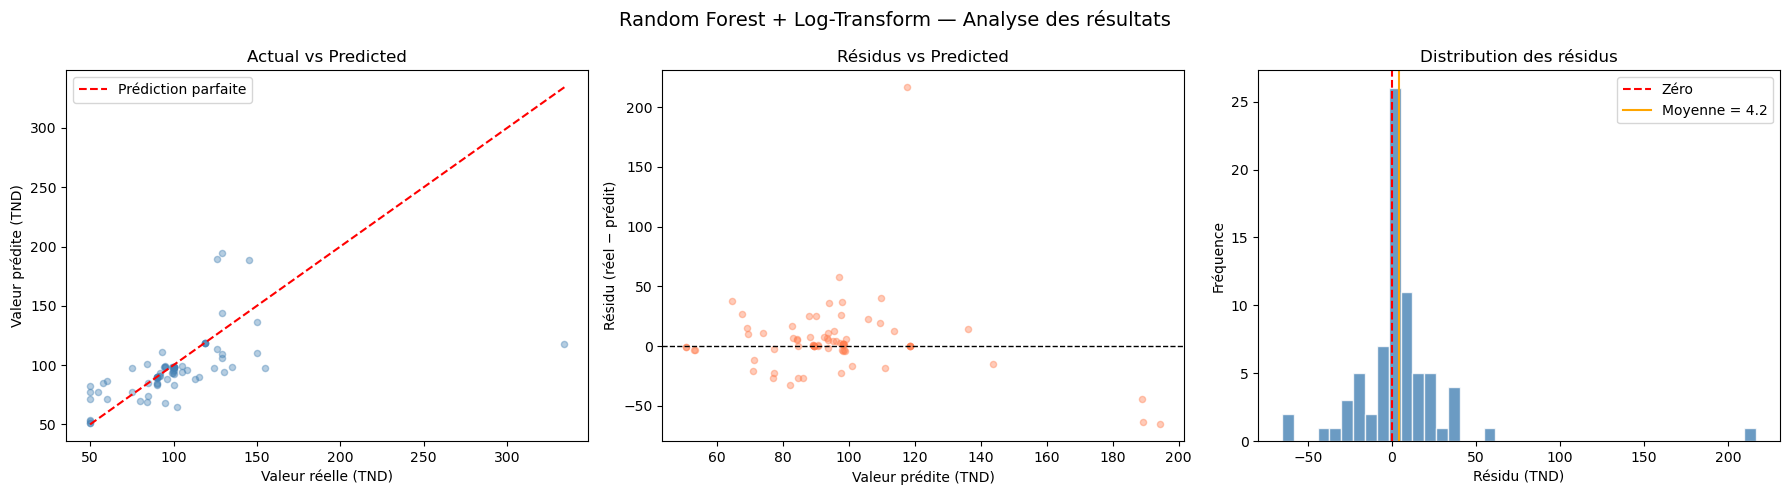

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Random Forest + Log-Transform — Analyse des résultats', fontsize=14)

# ── 1. Actual vs Predicted ────────────────────────────────────
ax = axes[0]
ax.scatter(y_test, y_pred_rf, alpha=0.4, color='steelblue', s=20)
lims = [min(y_test.min(), y_pred_rf.min()),
        max(y_test.max(), y_pred_rf.max())]
ax.plot(lims, lims, 'r--', linewidth=1.5, label='Prédiction parfaite')
ax.set_xlabel('Valeur réelle (TND)')
ax.set_ylabel('Valeur prédite (TND)')
ax.set_title('Actual vs Predicted')
ax.legend()

# ── 2. Résidus vs Predicted ───────────────────────────────────
ax = axes[1]
residus = y_test - y_pred_rf
ax.scatter(y_pred_rf, residus, alpha=0.4, color='coral', s=20)
ax.axhline(0, color='black', linestyle='--', linewidth=1)
ax.set_xlabel('Valeur prédite (TND)')
ax.set_ylabel('Résidu (réel − prédit)')
ax.set_title('Résidus vs Predicted')

# ── 3. Distribution des résidus ───────────────────────────────
ax = axes[2]
ax.hist(residus, bins=40, color='steelblue', edgecolor='white', alpha=0.8)
ax.axvline(0,            color='red',    linestyle='--', label='Zéro')
ax.axvline(residus.mean(), color='orange', linestyle='-',
           label=f'Moyenne = {residus.mean():.1f}')
ax.set_xlabel('Résidu (TND)')
ax.set_ylabel('Fréquence')
ax.set_title('Distribution des résidus')
ax.legend()

plt.tight_layout()
plt.savefig('rf_regression_results.png', dpi=150)
plt.show()


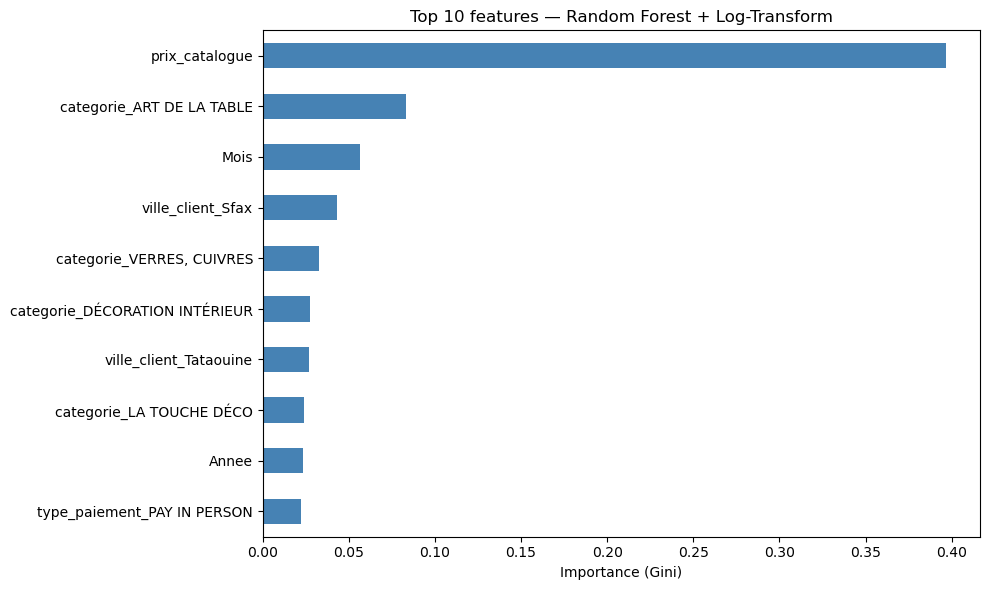


Top 10 features :
prix_catalogue                    0.3966
categorie_ART DE LA TABLE         0.0831
Mois                              0.0563
ville_client_Sfax                 0.0432
categorie_VERRES, CUIVRES         0.0326
categorie_DÉCORATION INTÉRIEUR    0.0272
ville_client_Tataouine            0.0269
categorie_LA TOUCHE DÉCO          0.0240
Annee                             0.0236
type_paiement_PAY IN PERSON       0.0220


In [18]:
# ── Feature Importance via TransformedTargetRegressor ────────
inner_pipe = grid_rf.best_estimator_.regressor_
rf_model   = inner_pipe.named_steps['model']
prep       = inner_pipe.named_steps['prep']

# Noms des features après OneHotEncoding
cat_feature_names = (prep
    .named_transformers_['cat']
    .get_feature_names_out(cat_cols)
    .tolist())
all_feature_names = list(num_cols) + cat_feature_names

# ── Top 10 features ───────────────────────────────────────────
importances = pd.Series(rf_model.feature_importances_,
                        index=all_feature_names).nlargest(10)

fig, ax = plt.subplots(figsize=(10, 6))
importances.sort_values().plot(kind='barh', ax=ax, color='steelblue')
ax.set_title('Top 10 features — Random Forest + Log-Transform')
ax.set_xlabel('Importance (Gini)')
plt.tight_layout()
plt.savefig('rf_feature_importance.png', dpi=150)
plt.show()

print('\nTop 10 features :')
print(importances.round(4).to_string())


# Gradient Boosting Regressor (with Log-Transform)


In [19]:
from sklearn.ensemble import GradientBoostingRegressor

# ── Pipeline GBR ──────────────────────────────────────────────
pipe_gbr = Pipeline([
    ('prep',  preprocessor),
    ('model', GradientBoostingRegressor(random_state=42))
])

# ── Wrap avec log-transform ───────────────────────────────────
wrapped_gbr = TransformedTargetRegressor(
    regressor=pipe_gbr,
    func=np.log1p,
    inverse_func=np.expm1
)

params_gbr = {
    'regressor__model__n_estimators': [100, 200, 300],
    'regressor__model__max_depth': [3, 5, 7],
    'regressor__model__learning_rate': [0.05, 0.1, 0.2],
    'regressor__model__min_samples_split': [2, 5],
}

grid_gbr = GridSearchCV(
    wrapped_gbr, params_gbr,
    cv=5, scoring='neg_mean_absolute_error',
    n_jobs=-1
)
grid_gbr.fit(X_train, y_train)

y_pred_gbr = grid_gbr.best_estimator_.predict(X_test)

print('── Gradient Boosting + Log-Transform ──')
print('Meilleurs paramètres :', grid_gbr.best_params_)
print('Meilleur score CV (MAE) :', round(-grid_gbr.best_score_, 2))


── Gradient Boosting + Log-Transform ──
Meilleurs paramètres : {'regressor__model__learning_rate': 0.05, 'regressor__model__max_depth': 5, 'regressor__model__min_samples_split': 2, 'regressor__model__n_estimators': 100}
Meilleur score CV (MAE) : 17.2


# Evaluation Metrics — Gradient Boosting


In [20]:
mae_gbr  = mean_absolute_error(y_test, y_pred_gbr)
rmse_gbr = np.sqrt(mean_squared_error(y_test, y_pred_gbr))
r2_gbr   = r2_score(y_test, y_pred_gbr)
mape_gbr = np.mean(np.abs((y_test - y_pred_gbr) /
                           y_test.replace(0, np.nan))) * 100

print('══════════════════════════════════════')
print('  Gradient Boosting + Log — Test Set')
print('══════════════════════════════════════')
print(f'  MAE   : {mae_gbr:.2f}  TND')
print(f'  RMSE  : {rmse_gbr:.2f} TND')
print(f'  R²    : {r2_gbr:.4f}')
print(f'  MAPE  : {mape_gbr:.2f} %')
print('══════════════════════════════════════')


══════════════════════════════════════
  Gradient Boosting + Log — Test Set
══════════════════════════════════════
  MAE   : 17.17  TND
  RMSE  : 35.75 TND
  R²    : 0.0675
  MAPE  : 16.29 %
══════════════════════════════════════


# Comparaison des Modeles 

In [21]:
df_compare = pd.DataFrame([
    {
        'Modèle': 'Random Forest + Log',
        'MAE (TND)':  round(mae_rf,  2),
        'RMSE (TND)': round(rmse_rf, 2),
        'R²':         round(r2_rf,   4),
        'MAPE (%)':   round(mape_rf, 2),
        'CV MAE':     round(-grid_rf.best_score_, 2)
    },
    {
        'Modèle': 'Gradient Boosting + Log',
        'MAE (TND)':  round(mae_gbr,  2),
        'RMSE (TND)': round(rmse_gbr, 2),
        'R²':         round(r2_gbr,   4),
        'MAPE (%)':   round(mape_gbr, 2),
        'CV MAE':     round(-grid_gbr.best_score_, 2)
    }
]).sort_values('MAE (TND)')

print('\n══════════════════════════════════════════════════')
print('  Tableau comparatif — Modèles de régression')
print('══════════════════════════════════════════════════')
print(df_compare.to_string(index=False))

# Meilleur modèle
best_name = df_compare.iloc[0]['Modèle']
print(f'\n  Meilleur modèle : {best_name}')
print(f'  → MAE = {df_compare.iloc[0]["MAE (TND)"]} TND')
print(f'  → R²  = {df_compare.iloc[0]["R²"]}')

# Sélection automatique du meilleur
if df_compare.iloc[0]['Modèle'] == 'Random Forest + Log':
    best_grid = grid_rf
    print('\n→ Random Forest sélectionné pour la sauvegarde')
else:
    best_grid = grid_gbr
    print('\n→ Gradient Boosting sélectionné pour la sauvegarde')



══════════════════════════════════════════════════
  Tableau comparatif — Modèles de régression
══════════════════════════════════════════════════
                 Modèle  MAE (TND)  RMSE (TND)     R²  MAPE (%)  CV MAE
    Random Forest + Log      15.88       32.09 0.2487     14.52   16.38
Gradient Boosting + Log      17.17       35.75 0.0675     16.29   17.20

  Meilleur modèle : Random Forest + Log
  → MAE = 15.88 TND
  → R²  = 0.2487

→ Random Forest sélectionné pour la sauvegarde


In [22]:
# ── Vérification du meilleur modèle ─────────────────────────
best_model = best_grid.best_estimator_
inner = best_model.regressor_
prep_check = inner.named_steps['prep']

print(f'Type du modèle : {type(best_model).__name__}')
print(f'  → Regressor  : {type(inner.named_steps["model"]).__name__}')
print(f'  → Transform  : log1p / expm1')

for name, transformer, cols in prep_check.transformers_:
    print(f'\n--- {name} : {list(cols)} ---')
    if hasattr(transformer, 'categories_'):
        for i, cat in enumerate(transformer.categories_):
            print(f'  col {i} : {cat[:5]}')


Type du modèle : TransformedTargetRegressor
  → Regressor  : RandomForestRegressor
  → Transform  : log1p / expm1

--- num : ['a_code_promo', 'prix_catalogue', 'En_Promo', 'Annee', 'Mois', 'est_saison_haute'] ---

--- cat : ['ville_client', 'canal_produit', 'categorie', 'type_paiement', 'Trimestre', 'Semestre'] ---
  col 0 : ['Ariana' 'Beja' 'Ben Arous' 'Bizerte' 'Gabes']
  col 1 : ['Site Web']
  col 2 : ['ART DE LA TABLE' 'ART DE TABLE' 'ARTICLES EN CUIVRE' 'ARTISANAT'
 "BOIS D'OLIVIER"]
  col 3 : ['AUTRE' 'PAY IN PERSON' 'PAYMEE' 'WALLET PAYMENT']
  col 4 : ['Trimestre 1' 'Trimestre 2' 'Trimestre 3' 'Trimestre 4']
  col 5 : ['Semestre 1' 'Semestre 2']


In [23]:
import joblib

# ── Sauvegarde du meilleur modèle ─────────────────────────
joblib.dump(best_grid.best_estimator_, 'model_regression.pkl')
joblib.dump(list(X_train.columns),     'feature_columns_regression.pkl')

print('✅ Modèle sauvegardé : model_regression.pkl')
print('✅ Colonnes sauvegardées : feature_columns_regression.pkl')
print(f'\nType : {type(best_grid.best_estimator_).__name__}')
print(f'Transform : log1p(y) → train → expm1(pred)')
print(f'\nColonnes ({len(list(X_train.columns))}) :')
for col in X_train.columns:
    print(f'  - {col}')

# ── Test avec estimation de quantité ──────────────────────
print(f'\n── Test : prédiction + quantité estimée ──')
test_preds = best_grid.best_estimator_.predict(X_test[:5])
test_prix  = X_test['prix_catalogue'].iloc[:5].values

for i, (real, pred, prix) in enumerate(zip(y_test[:5], test_preds, test_prix)):
    qty_est = max(1, round(pred / prix)) if prix > 0 else '?'
    print(f'  Commande {i+1} : réel={real:.0f} TND | prédit={pred:.0f} TND | catalogue={prix:.0f} TND | qté estimée≈{qty_est}')


✅ Modèle sauvegardé : model_regression.pkl
✅ Colonnes sauvegardées : feature_columns_regression.pkl

Type : TransformedTargetRegressor
Transform : log1p(y) → train → expm1(pred)

Colonnes (12) :
  - a_code_promo
  - ville_client
  - prix_catalogue
  - En_Promo
  - canal_produit
  - categorie
  - type_paiement
  - Annee
  - Mois
  - Trimestre
  - Semestre
  - est_saison_haute

── Test : prédiction + quantité estimée ──
  Commande 1 : réel=100 TND | prédit=98 TND | catalogue=25 TND | qté estimée≈4
  Commande 2 : réel=100 TND | prédit=83 TND | catalogue=50 TND | qté estimée≈2
  Commande 3 : réel=60 TND | prédit=86 TND | catalogue=20 TND | qté estimée≈4
  Commande 4 : réel=85 TND | prédit=85 TND | catalogue=30 TND | qté estimée≈3
  Commande 5 : réel=92 TND | prédit=91 TND | catalogue=92 TND | qté estimée≈1
